# SpaceX Falcon 9 — Predictive Analysis (Classification)

Trains and tunes four classification models (Logistic Regression, SVM, Decision
Tree, KNN) with `GridSearchCV` to predict whether the Falcon 9 first stage will
land successfully, then compares them and inspects the confusion matrix of the
best model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

BASE = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork"
X = pd.read_csv(f"{BASE}/datasets/dataset_part_3.csv").astype('float64')
Y = pd.read_csv(f"{BASE}/datasets/dataset_part_2.csv")['Class'].to_numpy()

X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)
print("train:", X_train.shape, " test:", X_test.shape)

train: (72, 83)  test: (18, 83)


## Logistic Regression

In [2]:
params = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr_cv = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=10)
lr_cv.fit(X_train, Y_train)
print("best params:", lr_cv.best_params_)
print("cv accuracy:", round(lr_cv.best_score_, 4), " test accuracy:", round(lr_cv.score(X_test, Y_test), 4))

best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
cv accuracy: 0.8464  test accuracy: 0.8333


C:\Users\q8mlg\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\q8mlg\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\q8mlg\AppData

## Support Vector Machine

In [3]:
params = {'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto']}
svm_cv = GridSearchCV(SVC(), params, cv=10)
svm_cv.fit(X_train, Y_train)
print("best params:", svm_cv.best_params_)
print("cv accuracy:", round(svm_cv.best_score_, 4), " test accuracy:", round(svm_cv.score(X_test, Y_test), 4))

best params: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
cv accuracy: 0.8625  test accuracy: 0.8333


## Decision Tree

In [4]:
params = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'],
          'max_depth': [2, 4, 6, 8, 10, None], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree_cv = GridSearchCV(DecisionTreeClassifier(random_state=2), params, cv=10)
tree_cv.fit(X_train, Y_train)
print("best params:", tree_cv.best_params_)
print("cv accuracy:", round(tree_cv.best_score_, 4), " test accuracy:", round(tree_cv.score(X_test, Y_test), 4))

best params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
cv accuracy: 0.8714  test accuracy: 0.7778


## K-Nearest Neighbors

In [5]:
params = {'n_neighbors': list(range(1, 11)), 'algorithm': ['auto'], 'p': [1, 2]}
knn_cv = GridSearchCV(KNeighborsClassifier(), params, cv=10)
knn_cv.fit(X_train, Y_train)
print("best params:", knn_cv.best_params_)
print("cv accuracy:", round(knn_cv.best_score_, 4), " test accuracy:", round(knn_cv.score(X_test, Y_test), 4))

best params: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
cv accuracy: 0.8482  test accuracy: 0.8333


## Model comparison

In [6]:
models = {'Logistic Regression': lr_cv, 'SVM': svm_cv, 'Decision Tree': tree_cv, 'KNN': knn_cv}
comparison = pd.DataFrame({
    'CV Accuracy': {k: v.best_score_ for k, v in models.items()},
    'Test Accuracy': {k: v.score(X_test, Y_test) for k, v in models.items()},
}).sort_values('CV Accuracy', ascending=False)
comparison

,CV Accuracy,Test Accuracy
Decision Tree,0.871429,0.777778
SVM,0.862500,0.833333
KNN,0.848214,0.833333
Logistic Regression,0.846429,0.833333


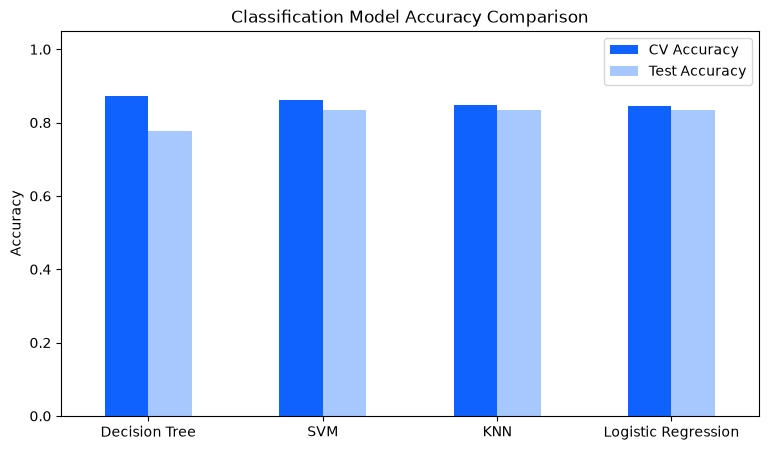

Best model by cross-validation accuracy: Decision Tree


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind='bar', ax=ax, color=['#0F62FE', '#A6C8FF'])
ax.set_ylabel('Accuracy'); ax.set_title('Classification Model Accuracy Comparison')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

best_name = comparison.index[0]
print("Best model by cross-validation accuracy:", best_name)

## Confusion matrix — best model

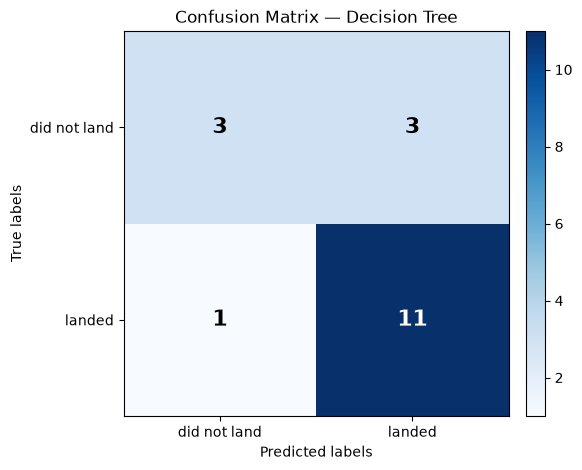

array([[ 3,  3],
       [ 1, 11]])

In [8]:
best_model = models[best_name]
Y_pred = best_model.predict(X_test)
cm = confusion_matrix(Y_test, Y_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap='Blues')
labels = ['did not land', 'landed']
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted labels'); ax.set_ylabel('True labels')
ax.set_title(f'Confusion Matrix — {best_name}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=16, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()
cm